In [143]:
import glob
import numpy
import pandas
import matplotlib.pyplot as plt
from tqdm import tqdm
import multiprocessing as mp
import os
from build import build_model
import coralme
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
from IPython.display import display, HTML, Math, Markdown
display(HTML("<style>.container { width:95% !important; }</style>"))

%load_ext autoreload
%autoreload 2

In [85]:
def get_carb_transport(model):
    transport = set()
    for met in carbs:
        e = model.get(met + "_e")
        if e is None: continue
        transport = transport | set(r for r in e.reactions if isinstance(r,coralme.core.reaction.MetabolicReaction))
    return transport

def get_transport_genes(transport):
    genes = set()
    for t in transport:
        genes = genes | set(t.genes)
    return genes

In [18]:
carbs = ["arab__L",
"cellb",
"drib",
"fru",
"fuc__L",
"gal",
"glc__D",
"glcn",
"lcts",
"malt",
"man",
"melib",
"mnl",
"oxa",
"rib__D",
"rmn",
"sucr",
"tre",
"xyl__D",
"strch1"]

In [101]:
results = {}
cond = "high_carbs"
for org in os.listdir("./cases/fluxes/{}/".format(cond)):
    if "Listeria" not in org: continue
    org = org.split(".csv")[0]
    model = coralme.io.pickle.load_pickle_me_model("./me-models/{}/MEModel-BIO-{}-ME-TS.pkl".format(org,org))
    transport = get_carb_transport(model)
    genes = get_transport_genes(transport)
    expression = ["translation_{}".format(g.id) for g in genes if "dummy" not in g.id]

    fluxes = pandas.read_csv("./cases/fluxes/{}/{}.csv".format(cond,org),index_col=0)["fluxes"]
    base_fluxes = pandas.read_csv("./cases/fluxes/base/{}.csv".format(org),index_col=0)["fluxes"]

    F = pandas.DataFrame()
    F["base"] = base_fluxes[expression]
    F[cond] = fluxes[expression]
    results[org] = F

Read LP format model from file /tmp/tmpz3wjw80g.lp
Reading time = 0.00 seconds
: 0 rows, 0 columns, 0 nonzeros
Read LP format model from file /tmp/tmpd16w2kvh.lp
Reading time = 0.00 seconds
: 1090 rows, 2590 columns, 11210 nonzeros
Read LP format model from file /tmp/tmpo9hrfwx3.lp
Reading time = 0.00 seconds
: 1115 rows, 2588 columns, 11010 nonzeros
Read LP format model from file /tmp/tmp_opebgni.lp
Reading time = 0.00 seconds
: 0 rows, 0 columns, 0 nonzeros
Read LP format model from file /tmp/tmpmdthsru3.lp
Reading time = 0.00 seconds
: 1102 rows, 2650 columns, 11440 nonzeros
Read LP format model from file /tmp/tmpybe4zzcd.lp
Reading time = 0.00 seconds
: 1127 rows, 2648 columns, 11240 nonzeros
Read LP format model from file /tmp/tmp3221i64u.lp
Reading time = 0.00 seconds
: 0 rows, 0 columns, 0 nonzeros
Read LP format model from file /tmp/tmp0whxlkug.lp
Reading time = 0.00 seconds
: 1102 rows, 2648 columns, 11432 nonzeros
Read LP format model from file /tmp/tmpyeofmpfh.lp
Reading tim

In [138]:
l = []
cutoff = 1e-16
for org,df in results.items():
    diff = (df[cond] - df["base"]).drop_duplicates()
    N = diff.shape[0]
    U = len(diff[diff>cutoff])
    D = len(diff[diff<-cutoff])
    l.append((N,U,D,U/N))

(array([2., 1., 2., 2., 0., 2., 0., 0., 0., 1.]),
 array([0.35714286, 0.38571429, 0.41428571, 0.44285714, 0.47142857,
        0.5       , 0.52857143, 0.55714286, 0.58571429, 0.61428571,
        0.64285714]),
 <BarContainer object of 10 artists>)

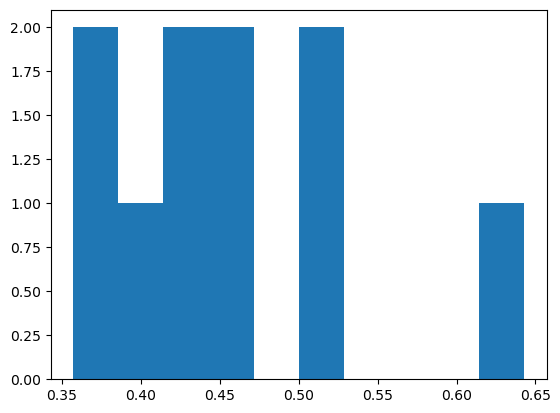

In [140]:
plt.hist([i[3] for i in l])

In [142]:
import numpy
p = [i[3] for i in l]
numpy.mean(p),numpy.min(p),numpy.max(p)

(np.float64(0.45669871794871797),
 np.float64(0.35714285714285715),
 np.float64(0.6428571428571429))